<a href="https://colab.research.google.com/github/jerry124/Aprendizaje-Automatico/blob/main/Practica_Regresion_Polinomial_Peso_Pez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Regresión Polinomial para predecir el peso de un pez

**Alumno:** Gerardo Valdez Martínez  
**Tema:** Regresión polinomial  
**Base de datos:** Fish.csv  

En esta práctica vamos a construir un modelo de Machine Learning para predecir el **peso de un pez** usando sus medidas físicas como longitud, altura, ancho y especie.

La idea principal es comparar una **regresión lineal normal** contra una **regresión polinomial**, para ver si al crear relaciones curvas entre las variables el modelo mejora.

---

## Objetivo

Aplicar regresión polinomial para predecir el peso de peces a partir de sus características físicas, evaluando el desempeño del modelo mediante métricas como **MAE**, **MSE**, **RMSE** y **R²**.


## 1. Importación de librerías

Primero importamos las librerías necesarias.  
Usaremos `pandas` para manejar la base de datos, `matplotlib` y `seaborn` para gráficas, y `scikit-learn` para construir los modelos.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente')

Librerías importadas correctamente


## 2. Carga de la base de datos

Para trabajar en Colab, sube el archivo **Fish.csv** cuando se te solicite.  
Si el archivo ya está en la carpeta de trabajo, el notebook lo leerá directamente.

In [ ]:
import os

if os.path.exists('Fish.csv'):
    df = pd.read_csv('Fish.csv')
else:
    try:
        from google.colab import files
        uploaded = files.upload()
        df = pd.read_csv('Fish.csv')
    except Exception:
        # Opción de respaldo por si se ejecuta en un entorno con internet
        url = 'https://raw.githubusercontent.com/ybifoundation/Dataset/main/Fish.csv'
        df = pd.read_csv(url)

df.head()

,Category,Species,Weight,Height,Width,Length1,Length2,Length3
0,1,Bream,242.0,11.5200,4.0200,23.2,25.4,30.0
1,1,Bream,290.0,12.4800,4.3056,24.0,26.3,31.2
2,1,Bream,340.0,12.3778,4.6961,23.9,26.5,31.1
3,1,Bream,363.0,12.7300,4.4555,26.3,29.0,33.5
4,1,Bream,430.0,12.4440,5.1340,26.5,29.0,34.0


## 3. Exploración inicial de los datos

Aquí revisamos cuántas filas y columnas tiene la base de datos, los nombres de las variables y el tipo de dato de cada columna.

In [ ]:
print('Tamaño de la base de datos:', df.shape)
print('\nColumnas:')
print(df.columns)
print('\nInformación general:')
df.info()

Tamaño de la base de datos: (159, 8)

Columnas:
Index(['Category', 'Species', 'Weight', 'Height', 'Width', 'Length1',
       'Length2', 'Length3'],
      dtype='object')

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  159 non-null    int64  
 1   Species   159 non-null    object 
 2   Weight    159 non-null    float64
 3   Height    159 non-null    float64
 4   Width     159 non-null    float64
 5   Length1   159 non-null    float64
 6   Length2   159 non-null    float64
 7   Length3   159 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 10.1+ KB


## 4. Revisión de valores nulos

Antes de entrenar cualquier modelo, es importante revisar si existen datos faltantes.  
Si hubiera valores nulos, podrían afectar el entrenamiento del modelo.

In [ ]:
df.isnull().sum()

,0
Category,0
Species,0
Weight,0
Height,0
Width,0
Length1,0
Length2,0
Length3,0


## 5. Estadística descriptiva

Con esta tabla podemos observar valores mínimos, máximos, promedios y desviaciones estándar de las variables numéricas.

In [ ]:
df.describe()

,Category,Weight,Height,Width,Length1,Length2,Length3
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,3.264151,398.326415,8.970994,4.417486,26.247170,28.415723,31.227044
std,1.704249,357.978317,4.286208,1.685804,9.996441,10.716328,11.610246
min,1.000000,0.000000,1.728400,1.047600,7.500000,8.400000,8.800000
25%,2.000000,120.000000,5.944800,3.385650,19.050000,21.000000,23.150000
50%,3.000000,273.000000,7.786000,4.248500,25.200000,27.300000,29.400000
75%,4.500000,650.000000,12.365900,5.584500,32.700000,35.500000,39.650000
max,7.000000,1650.000000,18.957000,8.142000,59.000000,63.400000,68.000000


## 6. Visualización de la variable objetivo

La variable que queremos predecir es **Weight**, es decir, el peso del pez.  
Con esta gráfica observamos cómo se distribuyen los pesos dentro de la base de datos.

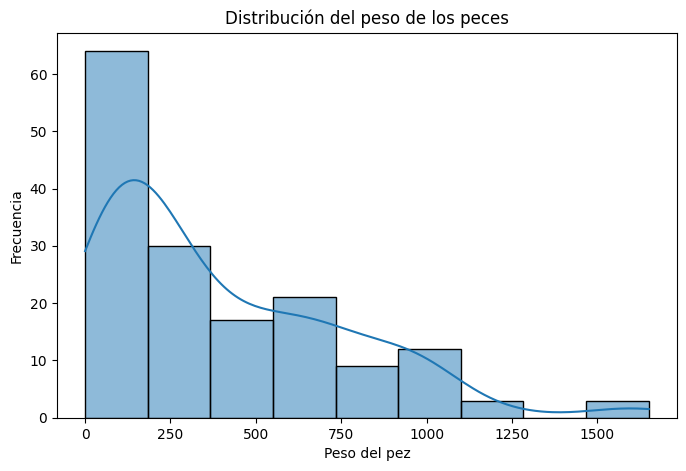

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Weight'], kde=True)
plt.title('Distribución del peso de los peces')
plt.xlabel('Peso del pez')
plt.ylabel('Frecuencia')
plt.show()

## 7. Relación entre variables numéricas y peso

En estas gráficas podemos ver si las medidas físicas del pez tienen relación con el peso.  
Normalmente, mientras más grande es el pez, mayor será su peso, pero esa relación no siempre es perfectamente lineal.

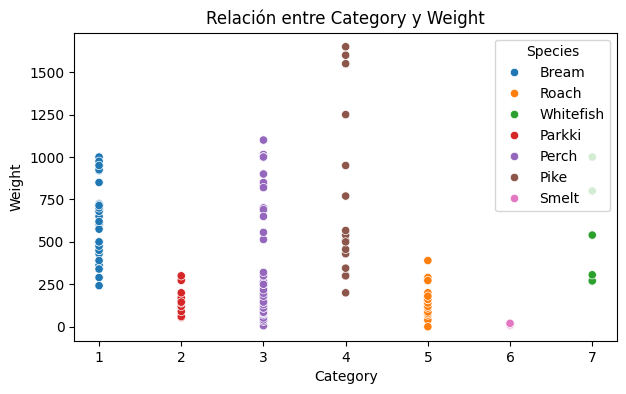

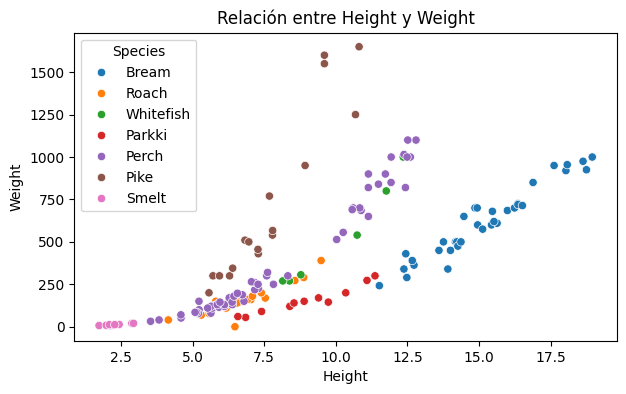

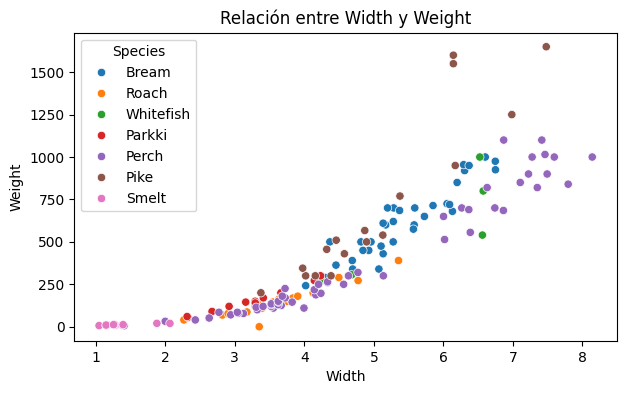

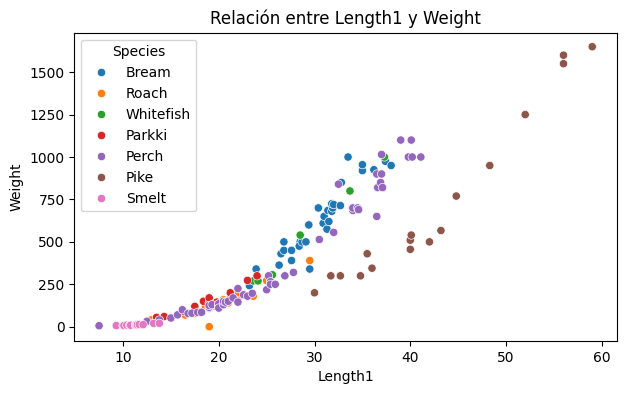

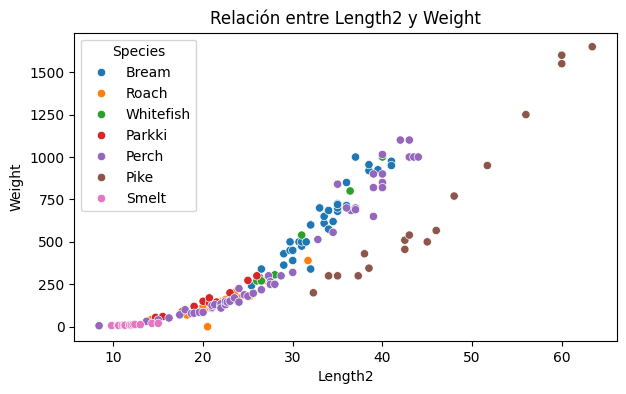

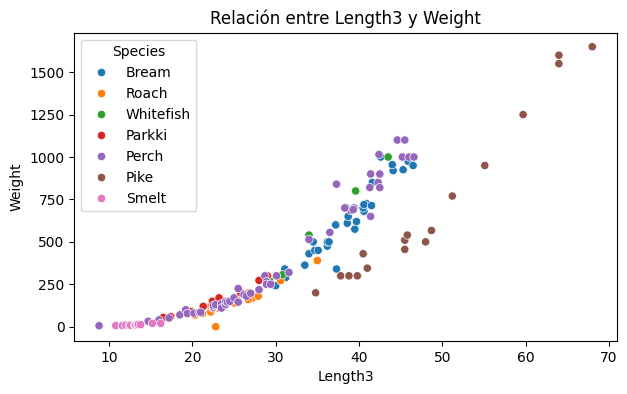

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
features_numeric = [col for col in numeric_cols if col != 'Weight']

for col in features_numeric:
    plt.figure(figsize=(7,4))
    sns.scatterplot(data=df, x=col, y='Weight', hue='Species' if 'Species' in df.columns else None)
    plt.title(f'Relación entre {col} y Weight')
    plt.xlabel(col)
    plt.ylabel('Weight')
    plt.show()

## 8. Matriz de correlación

La correlación ayuda a identificar qué variables numéricas tienen mayor relación con el peso.  
Valores cercanos a 1 indican una relación positiva fuerte.

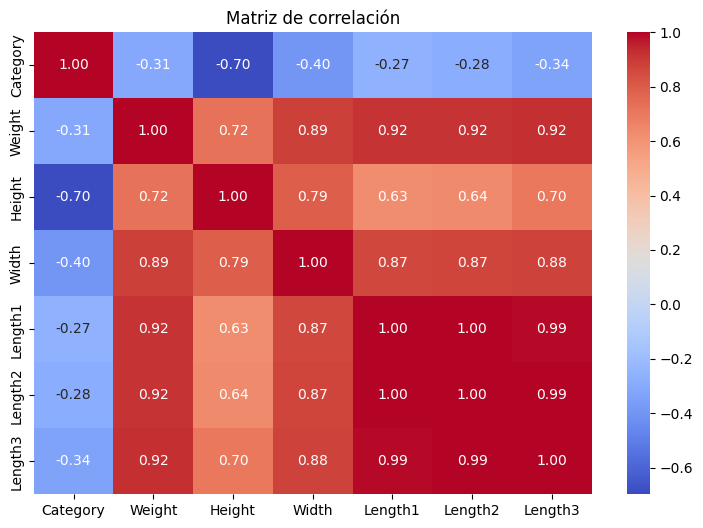

In [ ]:
plt.figure(figsize=(9,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

## 9. Separación de variables de entrada y salida

La variable de salida será **Weight**.  
Las variables de entrada serán las demás columnas disponibles en la base de datos.

En caso de que exista la columna **Species**, la usaremos como variable categórica porque la especie también puede influir en el peso.

In [ ]:
X = df.drop('Weight', axis=1)
y = df['Weight']

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print('Variables numéricas:', numeric_features)
print('Variables categóricas:', categorical_features)
print('Variable objetivo: Weight')

Variables numéricas: ['Category', 'Height', 'Width', 'Length1', 'Length2', 'Length3']
Variables categóricas: ['Species']
Variable objetivo: Weight


## 10. División de datos en entrenamiento y prueba

Dividimos la base de datos en dos partes:

- **80% entrenamiento:** para que el modelo aprenda.
- **20% prueba:** para evaluar si el modelo funciona con datos que no vio durante el entrenamiento.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Datos de entrenamiento:', X_train.shape)
print('Datos de prueba:', X_test.shape)

Datos de entrenamiento: (127, 7)
Datos de prueba: (32, 7)


## 11. Modelo 1: Regresión Lineal

Primero entrenamos una regresión lineal normal.  
Este modelo servirá como punto de comparación para saber si la regresión polinomial realmente mejora los resultados.

In [ ]:
preprocess_linear = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

modelo_lineal = Pipeline(steps=[
    ('preprocess', preprocess_linear),
    ('model', LinearRegression())
])

modelo_lineal.fit(X_train, y_train)
y_pred_lineal = modelo_lineal.predict(X_test)

mae_lineal = mean_absolute_error(y_test, y_pred_lineal)
mse_lineal = mean_squared_error(y_test, y_pred_lineal)
rmse_lineal = np.sqrt(mse_lineal)
r2_lineal = r2_score(y_test, y_pred_lineal)

print('Resultados del modelo lineal')
print('MAE :', mae_lineal)
print('MSE :', mse_lineal)
print('RMSE:', rmse_lineal)
print('R²  :', r2_lineal)

Resultados del modelo lineal
MAE : 65.30005153357405
MSE : 7007.383189854019
RMSE: 83.71011402365917
R²  : 0.9507352480054507


## 12. Modelo 2: Regresión Polinomial grado 2

Ahora aplicamos regresión polinomial de grado 2.  
Esto significa que el modelo no solo usará las variables originales, sino también combinaciones y potencias de ellas.

Por ejemplo, puede usar relaciones como:

\[
Length1^2, \quad Height^2, \quad Length1 	imes Width
\]

Esto permite que el modelo capture relaciones más curvas y complejas.

In [ ]:
numeric_poly_degree_2 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

preprocess_poly_2 = ColumnTransformer(
    transformers=[
        ('num_poly', numeric_poly_degree_2, numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

modelo_poly_2 = Pipeline(steps=[
    ('preprocess', preprocess_poly_2),
    ('model', Ridge(alpha=1.0))
])

modelo_poly_2.fit(X_train, y_train)
y_pred_poly_2 = modelo_poly_2.predict(X_test)

mae_poly_2 = mean_absolute_error(y_test, y_pred_poly_2)
mse_poly_2 = mean_squared_error(y_test, y_pred_poly_2)
rmse_poly_2 = np.sqrt(mse_poly_2)
r2_poly_2 = r2_score(y_test, y_pred_poly_2)

print('Resultados del modelo polinomial grado 2')
print('MAE :', mae_poly_2)
print('MSE :', mse_poly_2)
print('RMSE:', rmse_poly_2)
print('R²  :', r2_poly_2)

Resultados del modelo polinomial grado 2
MAE : 36.327856619717856
MSE : 2961.5375537748546
RMSE: 54.42001060064997
R²  : 0.9791791872720034


## 13. Comparación con distintos grados polinomiales

Probamos varios grados para observar cuál funciona mejor.  
Un grado muy bajo puede quedarse corto, pero un grado muy alto puede sobreajustarse.

In [ ]:
resultados = []

for degree in [1, 2, 3, 4]:
    if degree == 1:
        preprocessor = preprocess_linear
    else:
        numeric_poly = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=degree, include_bias=False))
        ])
        preprocessor = ColumnTransformer(
            transformers=[
                ('num_poly', numeric_poly, numeric_features),
                ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
            ]
        )

    model = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', Ridge(alpha=1.0))
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    resultados.append({
        'Grado': degree,
        'MAE': mean_absolute_error(y_test, pred),
      #  'MSE': mean_squared_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred)
    })

resultados_df = pd.DataFrame(resultados)
resultados_df

,Grado,MAE,RMSE,R2
0,1,68.793501,85.615575,0.948467
1,2,36.327857,54.420011,0.979179
2,3,35.612889,50.382284,0.982154
3,4,40.799513,59.389661,0.975203


## 14. Gráfica comparativa de R²

El valor de **R²** indica qué tanto explica el modelo la variabilidad del peso.  
Mientras más cercano a 1, mejor es el ajuste.

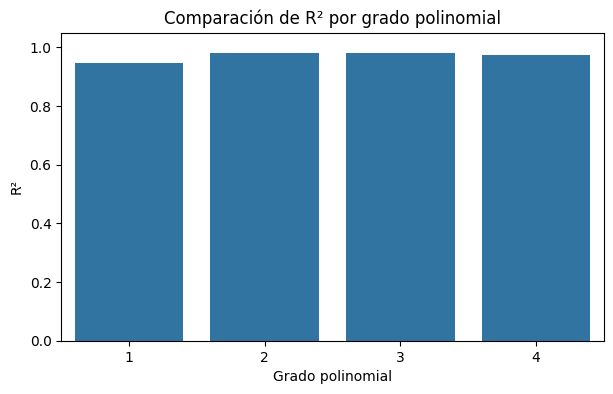

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(data=resultados_df, x='Grado', y='R2')
plt.title('Comparación de R² por grado polinomial')
plt.xlabel('Grado polinomial')
plt.ylabel('R²')
plt.ylim(0, 1.05)
plt.show()

## 15. Selección del mejor modelo

Seleccionamos como mejor modelo aquel que tenga el mayor valor de **R²** y errores bajos.  
Sin embargo, también debemos cuidar que el modelo no sea innecesariamente complejo.

In [ ]:
mejor_resultado = resultados_df.sort_values(by='R2', ascending=False).iloc[0]
mejor_grado = int(mejor_resultado['Grado'])

print('Mejor grado encontrado:', mejor_grado)
print(mejor_resultado)

Mejor grado encontrado: 3
Grado       3.000000
MAE        35.612889
MSE      2538.374567
RMSE       50.382284
R2          0.982154
Name: 2, dtype: float64


## 16. Gráfica: valores reales vs predichos

Esta gráfica compara el peso real contra el peso predicho por el modelo polinomial de grado 2.  
Si los puntos están cerca de la línea diagonal, significa que el modelo está prediciendo bien.

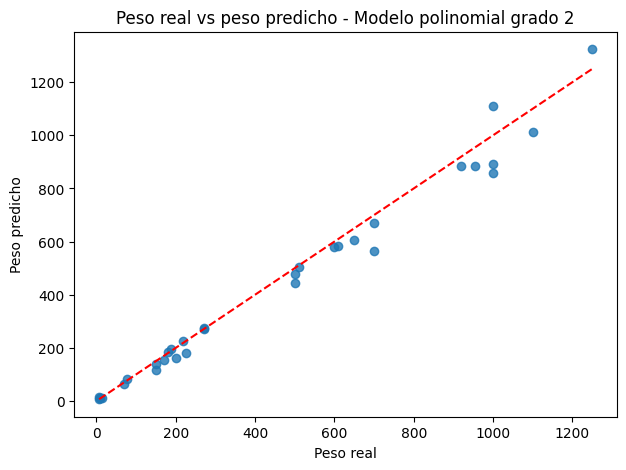

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_poly_2, alpha=0.8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Peso real vs peso predicho - Modelo polinomial grado 2')
plt.xlabel('Peso real')
plt.ylabel('Peso predicho')
plt.show()

## 17. Análisis de errores

Los residuos son la diferencia entre el valor real y el valor predicho.  
Un buen modelo debería tener errores distribuidos alrededor de cero.

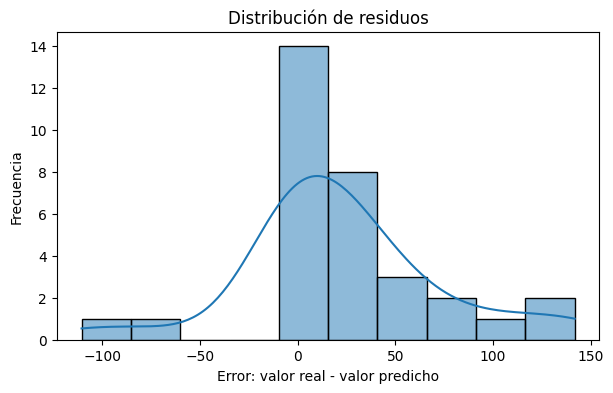

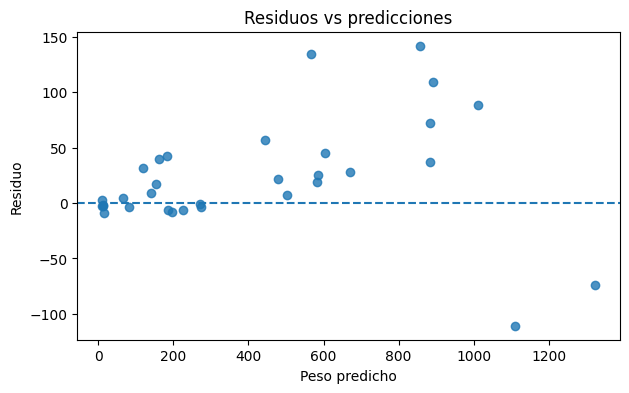

In [ ]:
residuos = y_test - y_pred_poly_2

plt.figure(figsize=(7,4))
sns.histplot(residuos, kde=True)
plt.title('Distribución de residuos')
plt.xlabel('Error: valor real - valor predicho')
plt.ylabel('Frecuencia')
plt.show()

plt.figure(figsize=(7,4))
plt.scatter(y_pred_poly_2, residuos, alpha=0.8)
plt.axhline(0, linestyle='--')
plt.title('Residuos vs predicciones')
plt.xlabel('Peso predicho')
plt.ylabel('Residuo')
plt.show()

## 18. Predicción con un nuevo pez

Ahora hacemos una predicción manual usando un ejemplo nuevo.  
Puedes modificar los valores para probar otros peces.

In [ ]:
# Creamos un ejemplo nuevo con la misma estructura de columnas que X
nuevo_pez = X.iloc[[0]].copy()

# Puedes cambiar estos valores según las columnas disponibles
print('Ejemplo usado para predecir:')
display(nuevo_pez)

prediccion = modelo_poly_2.predict(nuevo_pez)
print('Peso predicho del pez:', prediccion[0])

Ejemplo usado para predecir:


,Category,Species,Height,Width,Length1,Length2,Length3
0,1,Bream,11.52,4.02,23.2,25.4,30.0


Peso predicho del pez: 263.6973595693166


## 19. Interpretación de resultados

En esta práctica se observó que la regresión polinomial puede mejorar la predicción del peso del pez cuando la relación entre las medidas físicas y el peso no es completamente lineal.

La regresión lineal intenta ajustar una recta, mientras que la regresión polinomial permite ajustar una curva. Esto es útil porque el crecimiento de un pez no siempre aumenta de manera proporcional; por ejemplo, pequeños cambios en altura o ancho pueden producir cambios más grandes en el peso.

También se compararon diferentes grados polinomiales. Esto es importante porque un modelo más complejo no siempre significa un mejor modelo. Si el grado es demasiado alto, puede aprender demasiado los datos de entrenamiento y fallar con datos nuevos.


## 20. Conclusión

La regresión polinomial es una extensión de la regresión lineal que permite representar relaciones no lineales mediante potencias y combinaciones de las variables de entrada.

En el caso del peso de los peces, este enfoque resulta adecuado porque el peso depende de varias medidas físicas y su relación puede ser curva. Al comparar modelos, se puede observar qué grado polinomial ofrece mejor equilibrio entre precisión y generalización.

En conclusión, el modelo polinomial permite obtener una predicción más flexible del peso del pez y ayuda a comprender cómo las características físicas influyen en la variable objetivo.
